# Classic RBM vs RBM Energy Trained as an EBM

This notebook compares two models trained on the same binary MNIST data:

- `BBRBM`: classic Bernoulli-Bernoulli RBM trained with PCD/Gibbs.
- `BEBM + RBMEnergy`: the same visible free-energy family, but trained as a generic binary EBM with autograd and DMALA.

In [15]:
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from rbms.dataset import load_dataset
from rbms.io import load_model, load_params
from rbms.utils import get_saved_updates
from rbms.plot import plot_mult_PCA

plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["font.family"] = "STIXGeneral"
plt.rcParams.update({"font.size": 13})

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
dtype = torch.float32

train_dataset_name = "data/MNIST_train.h5"
test_dataset_name = "data/MNIST_test.h5"

MODEL_FILES = {
    "Classic RBM | PCD-10": "pcd_trains/BBRBM_MNIST_PCD10_h500_ch1024_lr1e-2_100k.h5",
    "BEBM RBMEnergy | DMALA-100": "pcd_trains/BEBM_RBMEnergy_MNIST_DMALA100_h500_ch1024_lr1e-2_100k.h5",
}

IMAGE_SHAPE = (28, 28)
PCA_POINT_SCALE = float(IMAGE_SHAPE[0])

print("device:", device)
for label, filename in MODEL_FILES.items():
    print(label, "->", filename)


device: cpu
Classic RBM | PCD-10 -> pcd_trains/BBRBM_MNIST_PCD10_h500_ch1024_lr1e-2_100k.h5
BEBM RBMEnergy | DMALA-100 -> pcd_trains/BEBM_RBMEnergy_MNIST_DMALA100_h500_ch1024_lr1e-2_100k.h5


## Load Data and Model Checkpoints


In [17]:
train_dataset, test_dataset = load_dataset(
    dataset_name=train_dataset_name,
    test_dataset_name=test_dataset_name,
    device=device,
    dtype=dtype,
)

train_visible = train_dataset.data.to(device=device, dtype=dtype)
num_visibles = train_dataset.get_num_visibles()

saved_updates_by_model = {label: get_saved_updates(filename) for label, filename in MODEL_FILES.items()}

for label, updates in saved_updates_by_model.items():
    print(label)
    print("  first update:", int(updates[0]))
    print("  last update: ", int(updates[-1]))
    print("  checkpoints: ", len(updates))


Reading dataset from data/MNIST_train.h5...
    Done
Reading dataset from data/MNIST_test.h5...
    Done
Classic RBM | PCD-10
  first update: 1
  last update:  100000
  checkpoints:  1000
BEBM RBMEnergy | DMALA-100
  first update: 1
  last update:  100000
  checkpoints:  1000


## Helpers


In [18]:
def selected_updates(updates, num_points):
    indices = np.linspace(0, len(updates) - 1, num_points).round().astype(int)
    indices = np.unique(indices)
    return np.asarray(updates)[indices]

def selected_updates_decades(updates):
    updates = np.asarray(updates)
    max_update = int(updates[-1])

    targets = [int(updates[0])]

    decade = 100
    while decade <= max_update:
        for multiplier in range(1, 10):
            target = multiplier * decade
            if target <= max_update:
                targets.append(target)
        decade *= 10

    targets.append(max_update)
    targets = np.unique(targets)

    selected = []
    for target in targets:
        index = np.argmin(np.abs(updates - target))
        selected.append(updates[index])

    return np.unique(selected)

def extract_rbm_tensors(params):
    if hasattr(params, "weight_matrix"):
        return params.weight_matrix, params.vbias, params.hbias

    energy = getattr(params, "energy", None)
    if energy is not None and all(hasattr(energy, name) for name in ["weight", "vbias", "hbias"]):
        return energy.weight, energy.vbias, energy.hbias

    raise TypeError(f"Could not extract RBM tensors from {type(params)}")


def read_weight_from_h5(filename, update):
    with h5py.File(filename, "r") as f:
        params_group = f[f"update_{int(update)}"]["params"]
        if "weight_matrix" in params_group:
            weight = params_group["weight_matrix"][()]
        elif "weight" in params_group:
            weight = params_group["weight"][()]
        else:
            raise KeyError(f"No RBM weight key found at update {update} in {filename}")
    return torch.as_tensor(weight, dtype=torch.float32)


def rbm_free_energy(visible, weight, vbias, hbias, beta=1.0):
    hidden_field = visible @ weight + hbias
    return -beta * (visible @ vbias + torch.nn.functional.softplus(hidden_field).sum(dim=1))


@torch.no_grad()
def sample_gibbs_visible(initial_visible, weight, vbias, hbias, num_steps):
    visible = initial_visible.clone()
    for _ in range(num_steps):
        hidden_prob = torch.sigmoid(visible @ weight + hbias)
        hidden = torch.bernoulli(hidden_prob)
        visible_prob = torch.sigmoid(hidden @ weight.t() + vbias)
        visible = torch.bernoulli(visible_prob)
    return visible


def sample_dmala_visible(initial_visible, weight, vbias, hbias, num_steps, alpha=0.5, beta=1.0):
    visible = initial_visible.clone().detach()
    acceptances = []

    for _ in range(num_steps):
        visible = visible.detach().requires_grad_(True)
        current_energy = rbm_free_energy(visible, weight, vbias, hbias, beta=beta)
        grad = torch.autograd.grad(current_energy.sum(), visible)[0]

        forward_logits = -0.5 * grad + (2.0 * visible - 1.0) / (2.0 * alpha)
        forward_prob = torch.sigmoid(forward_logits).clamp(1e-6, 1.0 - 1e-6)
        proposal = torch.bernoulli(forward_prob).detach()

        proposal_for_grad = proposal.detach().requires_grad_(True)
        proposal_energy = rbm_free_energy(proposal_for_grad, weight, vbias, hbias, beta=beta)
        proposal_grad = torch.autograd.grad(proposal_energy.sum(), proposal_for_grad)[0]

        reverse_logits = -0.5 * proposal_grad + (2.0 * proposal_for_grad - 1.0) / (2.0 * alpha)

        log_q_forward = -torch.nn.functional.binary_cross_entropy_with_logits(
            forward_logits,
            proposal,
            reduction="none",
        ).sum(dim=1)
        log_q_reverse = -torch.nn.functional.binary_cross_entropy_with_logits(
            reverse_logits,
            visible.detach(),
            reduction="none",
        ).sum(dim=1)

        log_accept = -proposal_energy.detach() + current_energy.detach() + log_q_reverse - log_q_forward
        accept = torch.log(torch.rand_like(log_accept)) < log_accept.clamp(max=0.0)
        visible = torch.where(accept[:, None], proposal, visible.detach())
        acceptances.append(accept.to(torch.float32).mean().detach())

    return visible.detach(), torch.stack(acceptances).mean().item()


def sample_visible(params, initial_visible, num_steps, kernel="gibbs", alpha=0.5):
    weight, vbias, hbias = extract_rbm_tensors(params)
    weight = weight.to(device=initial_visible.device, dtype=initial_visible.dtype)
    vbias = vbias.to(device=initial_visible.device, dtype=initial_visible.dtype)
    hbias = hbias.to(device=initial_visible.device, dtype=initial_visible.dtype)

    if kernel == "gibbs":
        return sample_gibbs_visible(initial_visible, weight, vbias, hbias, num_steps), None
    if kernel == "dmala":
        return sample_dmala_visible(initial_visible, weight, vbias, hbias, num_steps, alpha=alpha)
    raise ValueError(f"Unknown kernel: {kernel}")


def plot_binary_image_grid(visible, title, shape=(28, 28), grid_size=(8, 8)):
    visible = visible.detach().cpu()
    n_rows, n_cols = grid_size
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols, n_rows))
    for ax, img in zip(axes.ravel(), visible[: n_rows * n_cols]):
        ax.imshow(img.view(*shape), cmap="gray_r", vmin=0, vmax=1)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


## Eigenvalues of W^T W Over Training

For both models, `W` has shape `(num_visibles, num_hiddens)`. We plot the top eigenvalues of `W.T @ W`, i.e. the squared singular values of the visible-hidden weight matrix.


In [19]:
EIGEN_TOP_K = 10

eigen_history = {}

for label, filename in MODEL_FILES.items():
    updates = selected_updates_decades(saved_updates_by_model[label])
    top_eigs = []

    for update in tqdm(updates, desc=f"Eigenvalues: {label}"):
        weight = read_weight_from_h5(filename, update)
        singular_values = torch.linalg.svdvals(weight)
        eigvals = singular_values.square().sort(descending=True).values[:EIGEN_TOP_K]
        top_eigs.append(eigvals.cpu())

    eigen_history[label] = {"updates": updates, "top_eigs": torch.stack(top_eigs).numpy()}


Eigenvalues: Classic RBM | PCD-10: 100%|██████████| 29/29 [00:00<00:00, 71.07it/s]
Eigenvalues: BEBM RBMEnergy | DMALA-100: 100%|██████████| 29/29 [00:00<00:00, 69.35it/s]


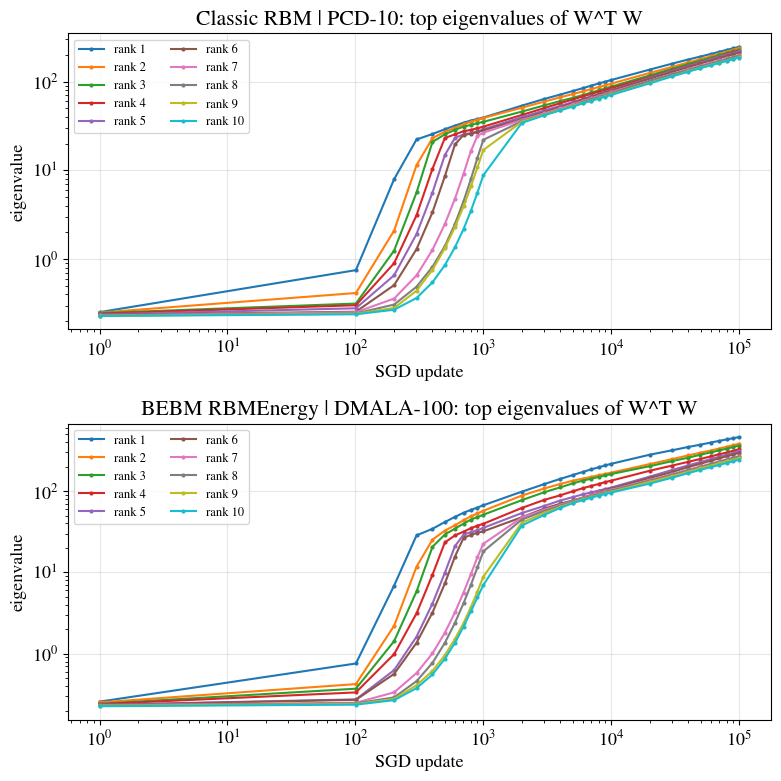

In [20]:
fig, axes = plt.subplots(len(MODEL_FILES), 1, figsize=(8, 4 * len(MODEL_FILES)), sharex=False)
if len(MODEL_FILES) == 1:
    axes = [axes]

for ax, (label, history) in zip(axes, eigen_history.items()):
    updates = history["updates"]
    top_eigs = history["top_eigs"]
    for rank in range(top_eigs.shape[1]):
        ax.plot(updates, top_eigs[:, rank], marker="o", markersize=2, label=f"rank {rank + 1}")
    ax.set_title(f"{label}: top eigenvalues of W^T W")
    ax.set_xlabel("SGD update")
    ax.set_ylabel("eigenvalue")
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=9)

plt.tight_layout()
plt.show()


## Data PCA Basis

All PCA plots use the covariance PCA basis of the training data, so both models are projected into the same visible-space coordinates.


In [21]:
with torch.no_grad():
    centered_data = train_visible - train_visible.mean(dim=0, keepdim=True)
    cov_data = centered_data.t() @ centered_data / max(1, train_visible.shape[0] - 1)
    _, _, V_dataT = torch.linalg.svd(cov_data)

    data_proj = train_visible @ V_dataT.mT
    data_proj = data_proj.detach().cpu().numpy()

print("data_proj", data_proj.shape)


data_proj (60000, 784)


## Final Permanent Chains in PCA Space

The archive stores only the latest `parallel_chains`, not one copy per checkpoint. So this cell compares final permanent chains only.


In [22]:
final_perm_proj = {}
final_perm_visible = {}

for label, filename in MODEL_FILES.items():
    final_update = int(saved_updates_by_model[label][-1])
    params, perm_chains, _ = load_model(filename, final_update, device=device, dtype=dtype)

    pc_proj = perm_chains["visible"] @ V_dataT.mT
    pc_proj = pc_proj.cpu().numpy()

    final_perm_visible[label] = perm_chains["visible"].detach().cpu()
    final_perm_proj[label] = pc_proj

    print(label, "update", final_update, "chains", tuple(perm_chains["visible"].shape))


Classic RBM | PCD-10 update 100000 chains (1024, 784)
BEBM RBMEnergy | DMALA-100 update 100000 chains (1024, 784)


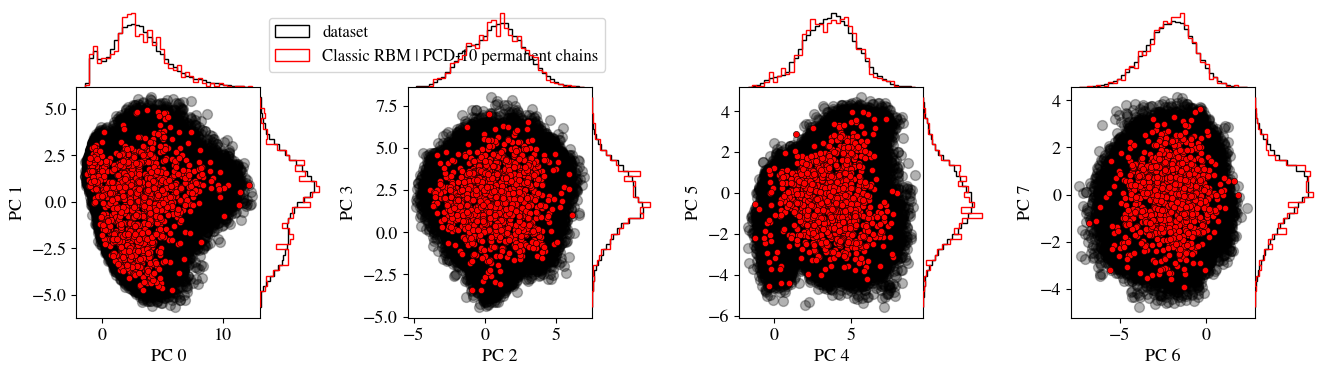

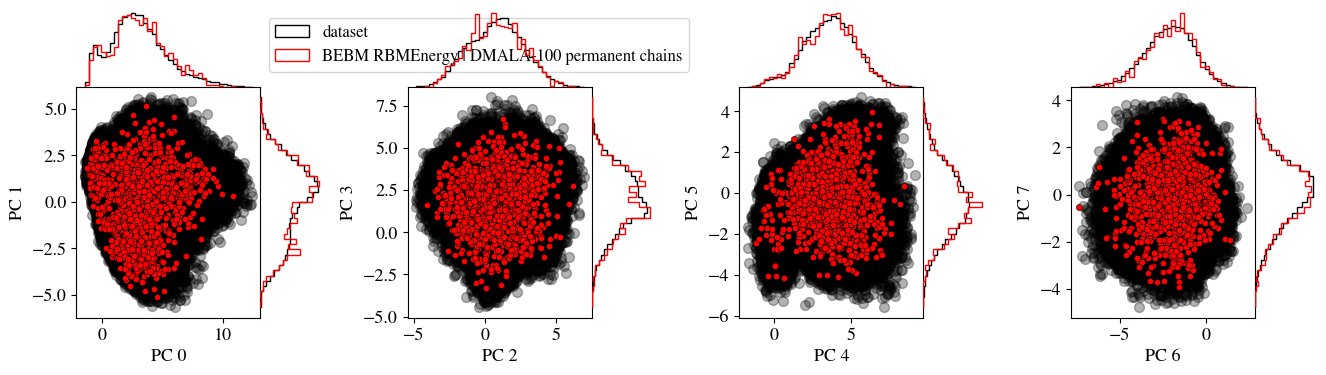

In [23]:
for label, pc_proj in final_perm_proj.items():
    plot_mult_PCA(
        data_proj[:, :8],
        pc_proj[:, :8],
        labels=["dataset", f"{label} permanent chains"],
    )


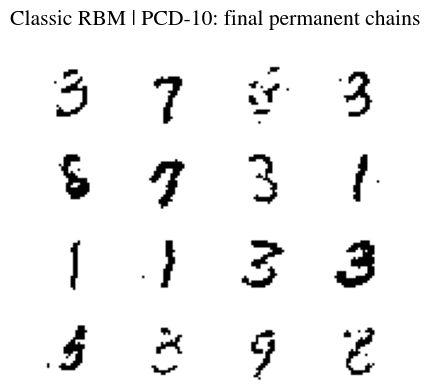

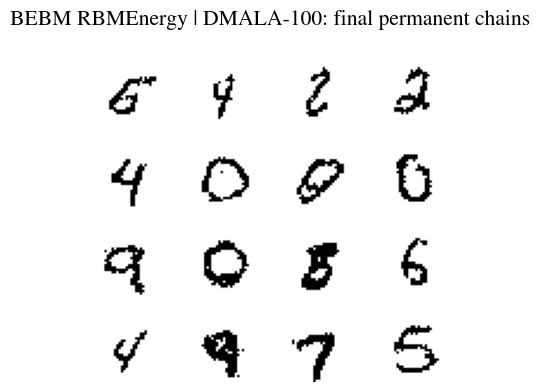

In [24]:
for label, visible in final_perm_visible.items():
    plot_binary_image_grid(visible=visible, title=f"{label}: final permanent chains", shape=IMAGE_SHAPE, grid_size=(4, 4))


## Generated Samples Over Training

For selected checkpoints, we generate samples from the same initial Bernoulli noise. The default kernel here is Gibbs, because both compared models are RBM visible-free-energy models and Gibbs is available for both.


In [25]:
TRAINING_SAMPLE_NUM_CHECKPOINTS = 5
TRAINING_SAMPLE_NUM_CHAINS = 512
TRAINING_SAMPLE_STEPS = 10000
TRAINING_SAMPLE_KERNEL = "gibbs"  # change to "dmala" if desired
TRAINING_DMALA_ALPHA = 0.5

sample_updates_by_model = {label: selected_updates(saved_updates_by_model[label], TRAINING_SAMPLE_NUM_CHECKPOINTS) for label in MODEL_FILES}

training_samples = {}
training_sample_proj = {}

torch.manual_seed(0)
initial_visible = torch.bernoulli(torch.full((TRAINING_SAMPLE_NUM_CHAINS, num_visibles), 0.5, device=device, dtype=dtype))

for label, filename in MODEL_FILES.items():
    training_samples[label] = {}
    training_sample_proj[label] = {}

    for update in tqdm(sample_updates_by_model[label], desc=f"Samples over training: {label}"):
        params = load_params(filename, int(update), device=device, dtype=dtype)
        visible, acceptance = sample_visible(params=params, initial_visible=initial_visible, num_steps=TRAINING_SAMPLE_STEPS, kernel=TRAINING_SAMPLE_KERNEL, alpha=TRAINING_DMALA_ALPHA)

        pc_proj = visible @ V_dataT.mT
        pc_proj = pc_proj.cpu().numpy()

        training_samples[label][int(update)] = visible.detach().cpu()
        training_sample_proj[label][int(update)] = pc_proj

        if acceptance is not None:
            print(label, int(update), "DMALA acceptance", acceptance)


Samples over training: Classic RBM | PCD-10: 100%|██████████| 5/5 [02:54<00:00, 34.97s/it]
Samples over training: BEBM RBMEnergy | DMALA-100: 100%|██████████| 5/5 [02:49<00:00, 33.85s/it]


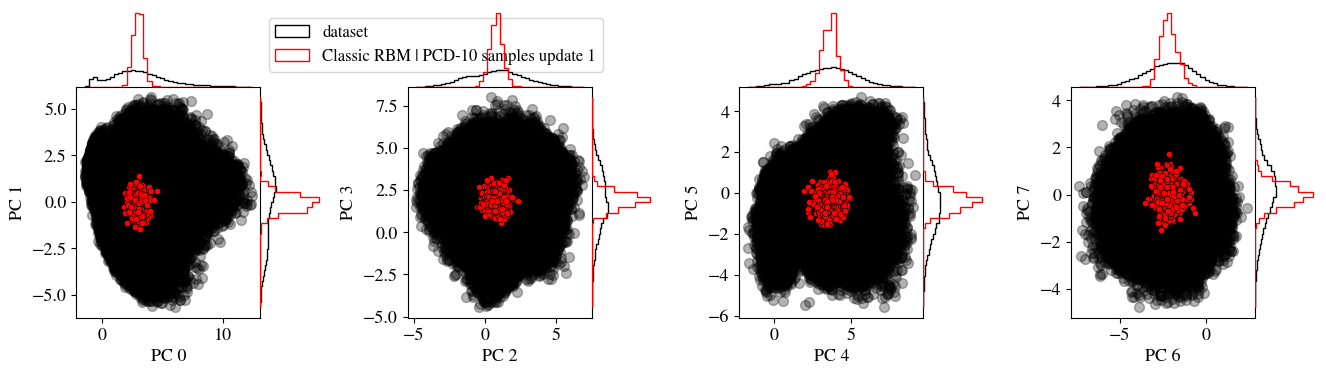

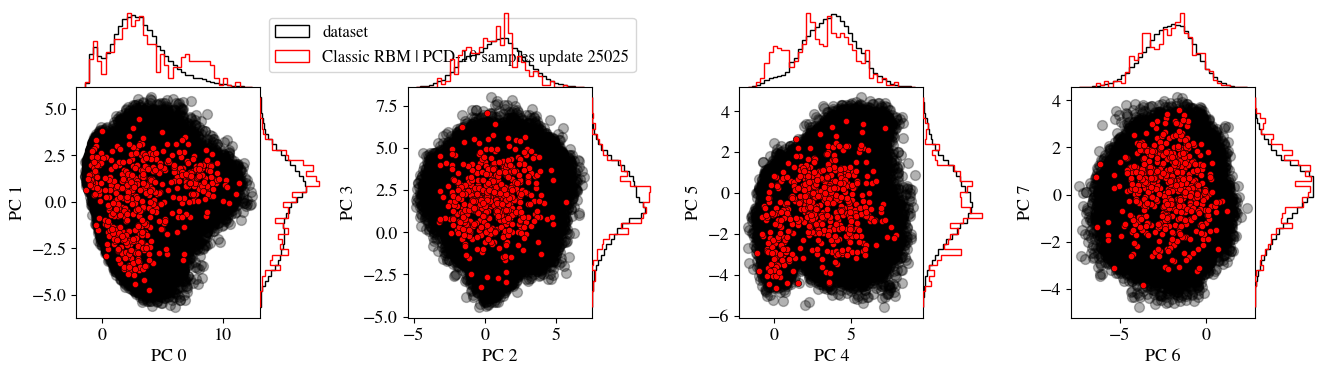

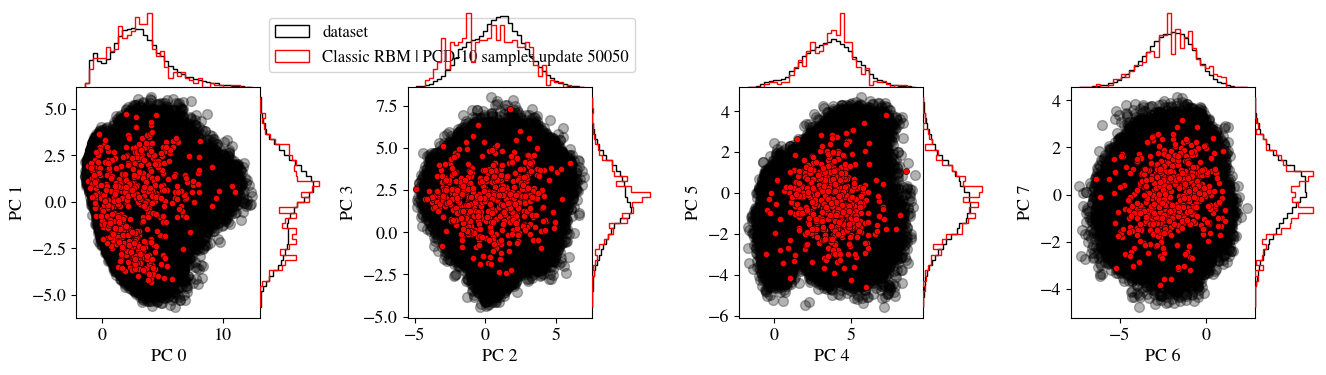

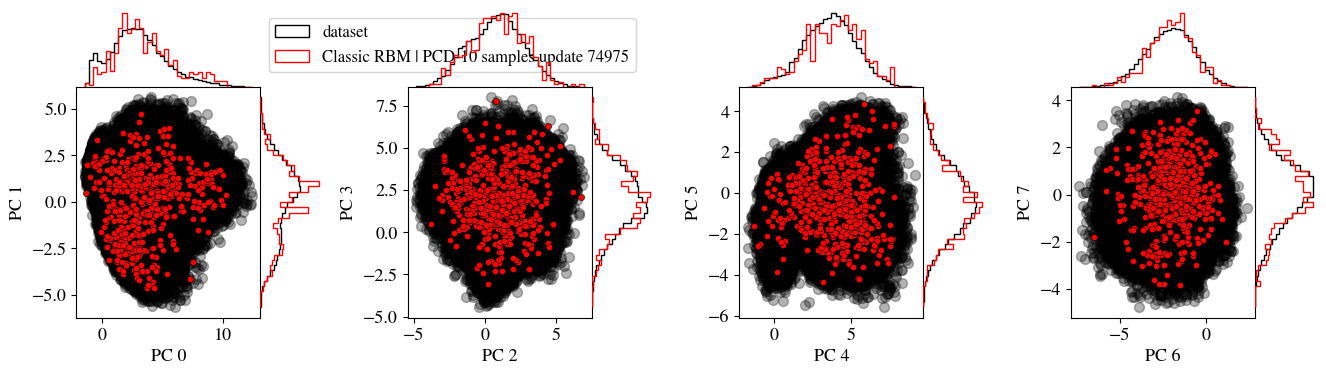

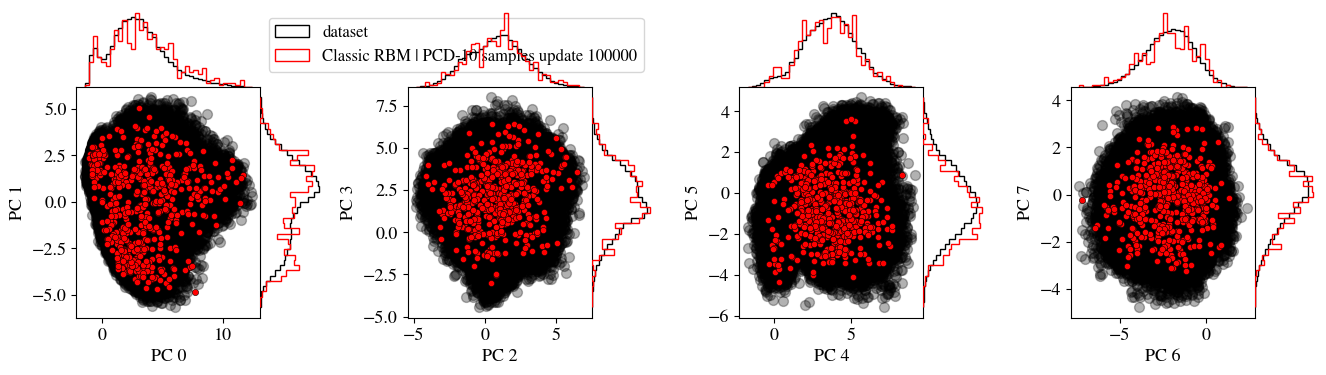

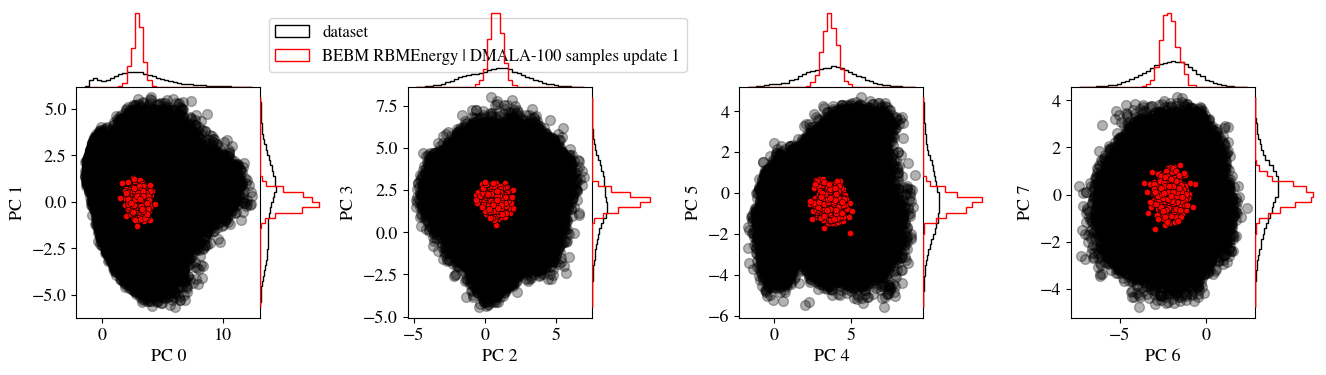

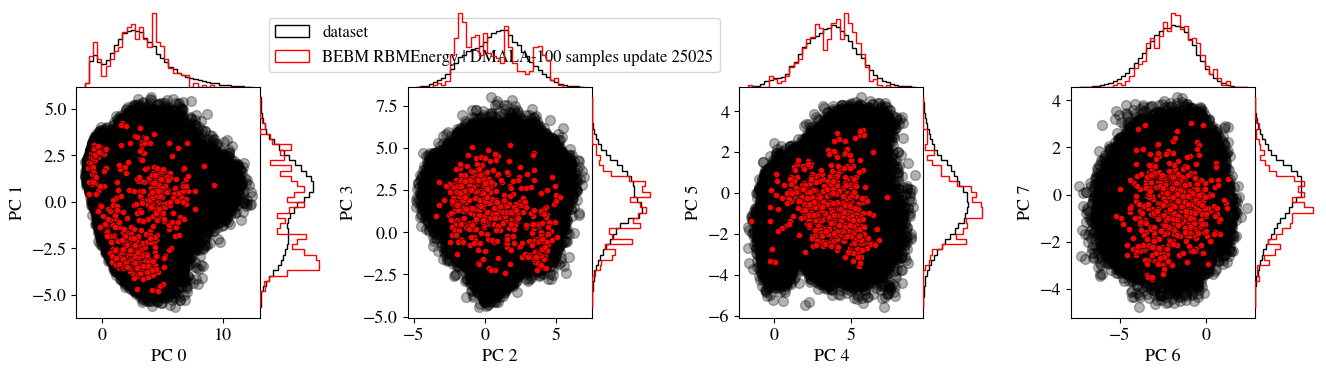

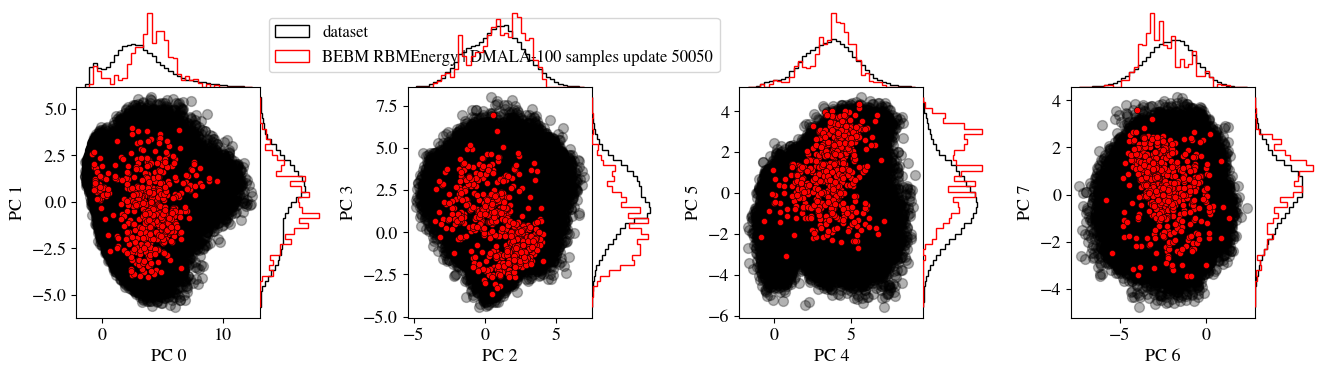

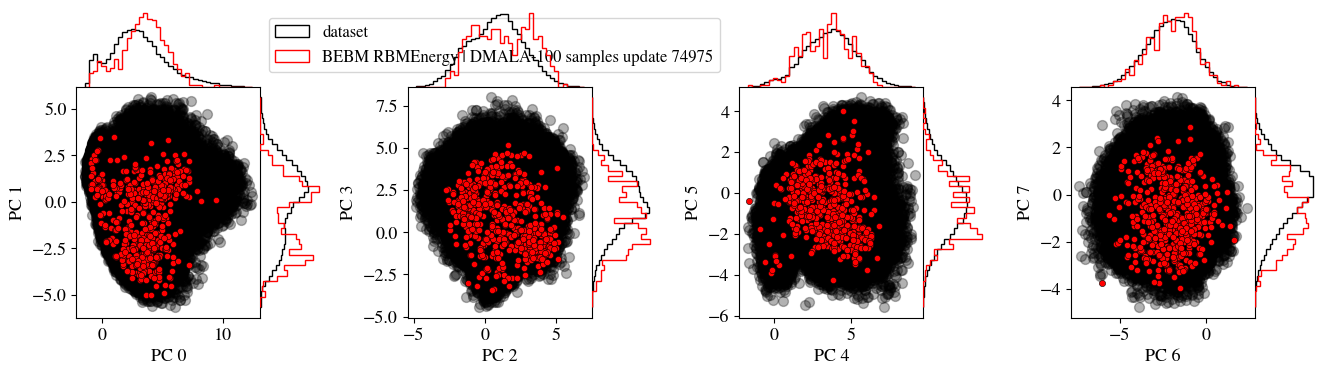

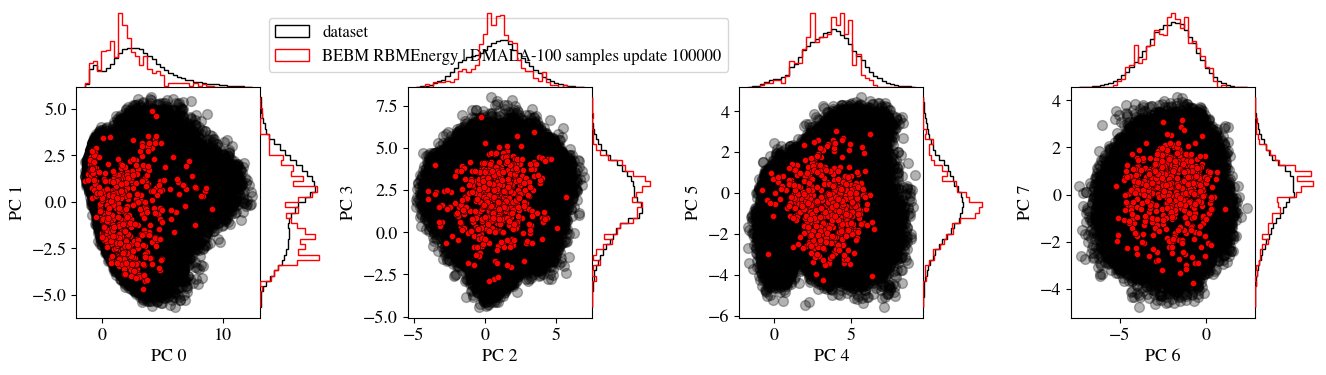

In [26]:
for label, proj_by_update in training_sample_proj.items():
    for update, pc_proj in proj_by_update.items():
        plot_mult_PCA(
            data_proj[:, :8],
            pc_proj[:, :8],
            labels=["dataset", f"{label} samples update {update}"],
        )


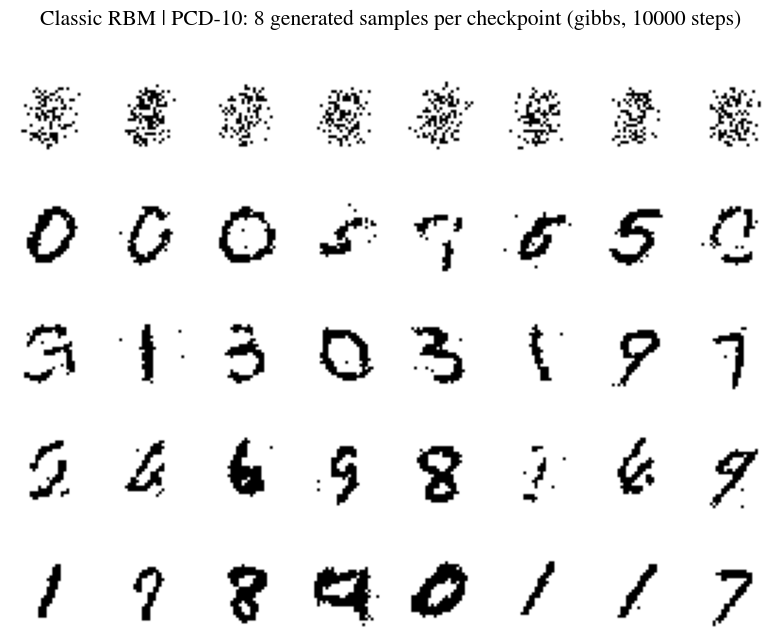

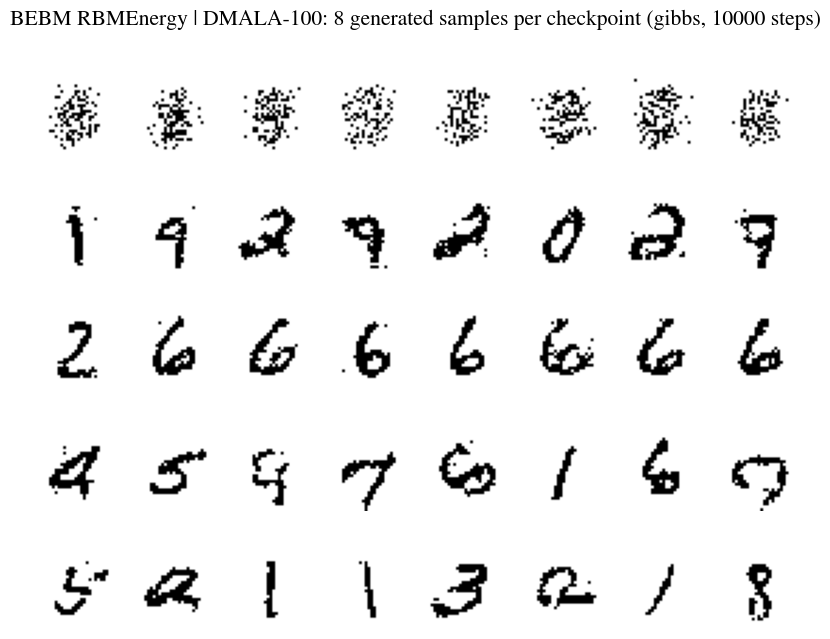

In [27]:
SAMPLES_PER_CHECKPOINT = 8

for label, samples_by_update in training_samples.items():
    num_rows = len(samples_by_update)
    fig, axes = plt.subplots(
        num_rows,
        SAMPLES_PER_CHECKPOINT,
        figsize=(SAMPLES_PER_CHECKPOINT, 1.35 * num_rows),
        squeeze=False,
    )

    for row, (update, visible) in enumerate(samples_by_update.items()):
        for col in range(SAMPLES_PER_CHECKPOINT):
            ax = axes[row, col]
            ax.imshow(visible[col].view(*IMAGE_SHAPE), cmap="gray_r", vmin=0, vmax=1)
            ax.axis("off")

        axes[row, 0].set_ylabel(
            f"update {update}",
            rotation=0,
            labelpad=40,
            va="center",
            fontsize=10,
        )

    fig.suptitle(f"{label}: {SAMPLES_PER_CHECKPOINT} generated samples per checkpoint ({TRAINING_SAMPLE_KERNEL}, {TRAINING_SAMPLE_STEPS} steps)")
    plt.tight_layout()
    plt.show()


## Mixing-Time Diagnostics

For each final model we run both kernels in the same order:

1. DMALA on the visible free energy.
2. Gibbs using the RBM hidden-variable conditionals.

We compute the normalized spin autocorrelation and fit an exponential decay `rho(tau) ~= A exp(-tau / tau_exp)`.


In [28]:
def spin_autocorr_fft(spins, max_lag, component_batch=4096, fft_device=None):
    if fft_device is None:
        fft_device = device

    num_times, num_chains, num_visibles = spins.shape
    max_lag = min(max_lag, num_times - 1)

    mean_spin = spins.to(torch.float32).mean(dim=(0, 1)).cpu()
    flat = spins.reshape(num_times, num_chains * num_visibles)
    n_fft = 1 << (2 * num_times - 1).bit_length()

    counts = torch.arange(num_times, num_times - max_lag - 1, -1, device=fft_device, dtype=torch.float32)

    numerator = torch.zeros(max_lag + 1, dtype=torch.float64)
    denominator = torch.tensor(0.0, dtype=torch.float64)

    for col_start in tqdm(range(0, flat.shape[1], component_batch), leave=False):
        col_stop = min(col_start + component_batch, flat.shape[1])
        block = flat[:, col_start:col_stop].to(device=fft_device, dtype=torch.float32)

        pixel_indices = torch.arange(col_start, col_stop, device="cpu") % num_visibles
        block = block - mean_spin[pixel_indices].to(fft_device).view(1, -1)

        block_fft = torch.fft.rfft(block, n=n_fft, dim=0)
        autocov = torch.fft.irfft(block_fft.abs().square(), n=n_fft, dim=0)[: max_lag + 1]
        autocov = autocov / counts[:, None]

        numerator += autocov.sum(dim=1).detach().cpu().double()
        denominator += autocov[0].sum().detach().cpu().double()

    return (numerator / denominator.clamp_min(1e-12)).numpy()


def collect_spin_trajectory(params, kernel, num_chains, num_steps, alpha=0.5):
    weight, vbias, hbias = extract_rbm_tensors(params)
    weight = weight.to(device=device, dtype=dtype)
    vbias = vbias.to(device=device, dtype=dtype)
    hbias = hbias.to(device=device, dtype=dtype)

    visible = torch.bernoulli(torch.full((num_chains, num_visibles), 0.5, device=device, dtype=dtype))
    spins = torch.empty((num_steps + 1, num_chains, num_visibles), dtype=torch.int8, device="cpu")
    acceptances = []

    for step in tqdm(range(num_steps + 1), desc=f"trajectory {kernel}"):
        spins[step].copy_((2.0 * visible.detach().cpu() - 1.0).to(torch.int8))

        if step < num_steps:
            if kernel == "gibbs":
                visible = sample_gibbs_visible(visible, weight, vbias, hbias, 1)
            elif kernel == "dmala":
                visible, acceptance = sample_dmala_visible(visible, weight, vbias, hbias, 1, alpha=alpha)
                acceptances.append(acceptance)
            else:
                raise ValueError(kernel)

    mean_acceptance = float(np.mean(acceptances)) if acceptances else None
    return spins, mean_acceptance


In [29]:
MIX_NUM_CHAINS = 256
MIX_NUM_STEPS = 30_000
MIX_MAX_LAG = 20_000
MIX_DMALA_ALPHA = 0.5
MIX_KERNELS = ["dmala", "gibbs"]

mixing_curves = {}
mixing_acceptance = {}

for label, filename in MODEL_FILES.items():
    final_update = int(saved_updates_by_model[label][-1])
    params = load_params(filename, final_update, device=device, dtype=dtype)
    mixing_curves[label] = {}
    mixing_acceptance[label] = {}

    for kernel in MIX_KERNELS:
        spins, acceptance = collect_spin_trajectory(params=params, kernel=kernel, num_chains=MIX_NUM_CHAINS, num_steps=MIX_NUM_STEPS, alpha=MIX_DMALA_ALPHA)
        mixing_curves[label][kernel] = spin_autocorr_fft(spins, max_lag=MIX_MAX_LAG, fft_device=device)
        mixing_acceptance[label][kernel] = acceptance
        if acceptance is not None:
            print(label, kernel, "acceptance", acceptance)


trajectory dmala: 100%|██████████| 30001/30001 [02:47<00:00, 178.93it/s]


Classic RBM | PCD-10 dmala acceptance 0.015375520833333333


trajectory dmala: 100%|██████████| 30001/30001 [02:53<00:00, 172.44it/s]


BEBM RBMEnergy | DMALA-100 dmala acceptance 0.020954296875


trajectory gibbs: 100%|██████████| 30001/30001 [00:52<00:00, 575.40it/s]


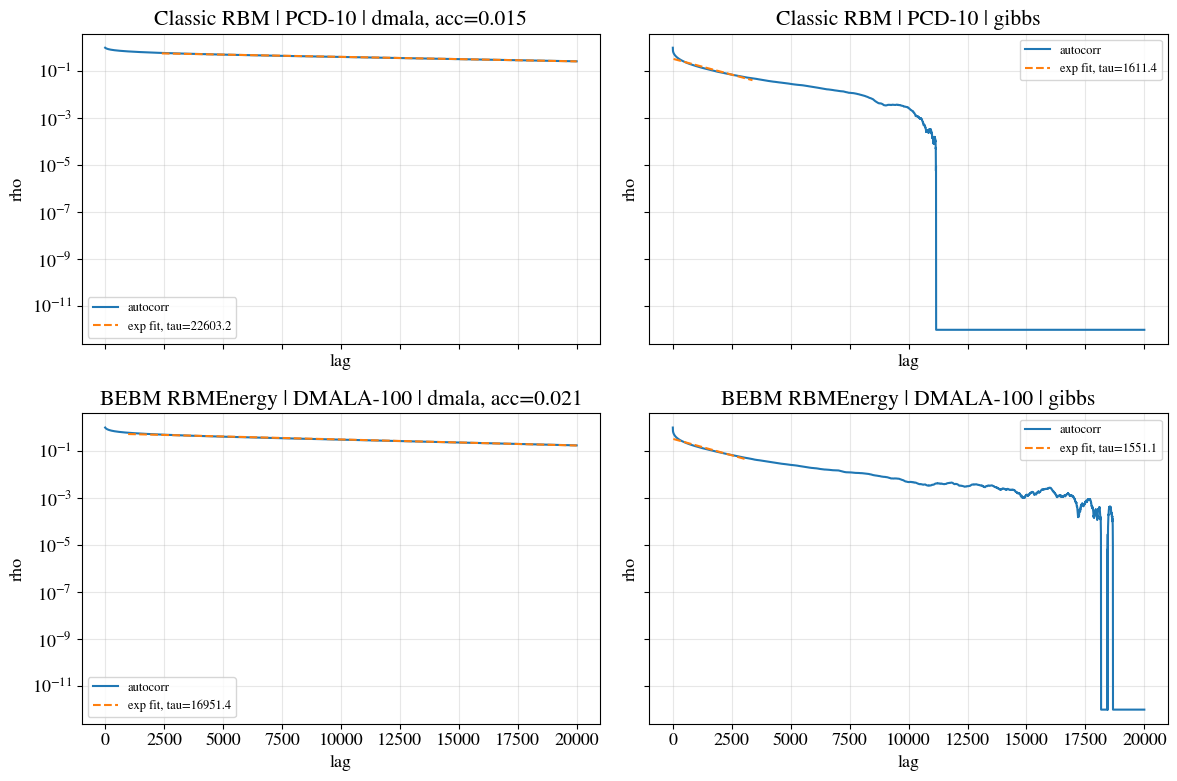

Classic RBM | PCD-10
  dmala: tau = 22603.24 steps
  gibbs: tau = 1611.40 steps
BEBM RBMEnergy | DMALA-100
  dmala: tau = 16951.38 steps
  gibbs: tau = 1551.10 steps


In [30]:
FIT_MIN_RHO = 0.05
FIT_MAX_RHO = 0.6
mixing_tau = {}

fig, axes = plt.subplots(len(MODEL_FILES), len(MIX_KERNELS), figsize=(6 * len(MIX_KERNELS), 4 * len(MODEL_FILES)), sharex=True, sharey=True)
if len(MODEL_FILES) == 1:
    axes = axes[None, :]

for row, (label, curves_by_kernel) in enumerate(mixing_curves.items()):
    mixing_tau[label] = {}

    for col, kernel in enumerate(MIX_KERNELS):
        ax = axes[row, col]
        rho = curves_by_kernel[kernel]
        lags = np.arange(len(rho))
        rho_positive = np.clip(rho, 1e-12, None)

        ax.plot(lags, rho_positive, label="autocorr")

        fit_mask = (lags > 0) & np.isfinite(rho) & (rho > FIT_MIN_RHO) & (rho < FIT_MAX_RHO)

        if fit_mask.sum() >= 2:
            slope, intercept = np.polyfit(lags[fit_mask], np.log(rho[fit_mask]), deg=1)
            tau_exp = -1.0 / slope if slope < 0 else np.inf
            fit_lags = lags[fit_mask]
            fit_curve = np.exp(intercept + slope * fit_lags)
            ax.plot(fit_lags, fit_curve, "--", label=f"exp fit, tau={tau_exp:.1f}")
        else:
            tau_exp = np.nan

        mixing_tau[label][kernel] = tau_exp
        acceptance = mixing_acceptance[label][kernel]
        accept_text = "" if acceptance is None else f", acc={acceptance:.3f}"

        ax.set_title(f"{label} | {kernel}{accept_text}")
        ax.set_xlabel("lag")
        ax.set_ylabel("rho")
        ax.set_yscale("log")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

for label, tau_by_kernel in mixing_tau.items():
    print(label)
    for kernel, tau_exp in tau_by_kernel.items():
        print(f"  {kernel}: tau = {tau_exp:.2f} steps")
